The **problem statement** is to build a machine learning model that can predict heart disease based on patient health data.

**Objective**
1) To analyze patient health data
2) To build and compare machine learning models for heart disease prediction
3) To evaluate model performance using appropriate metrics
4) To select the best-performing model for prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Rows - 303
# column - 14
df.shape

(303, 14)

In [5]:
# non null values are present in columns so need of null processing
# object column is not present
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
# checking null values
# no missing values are present
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# Right skewed - trestbps, chol, 
# left skewed - thalach
# little bit skewed data is present
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
# data is not ither banced or embanced
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [9]:
# seperating the numerical columns for finding the outliers
num_col = ['age','trestbps','chol','thalach','oldpeak']

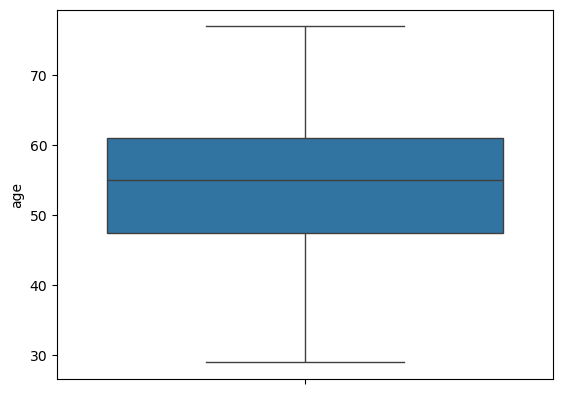

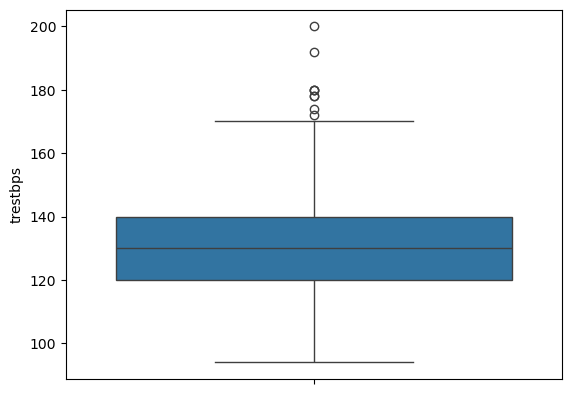

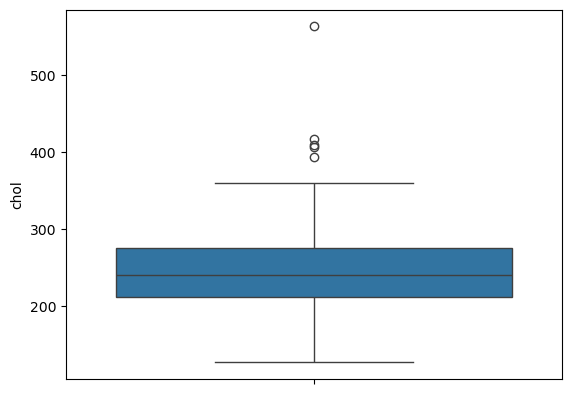

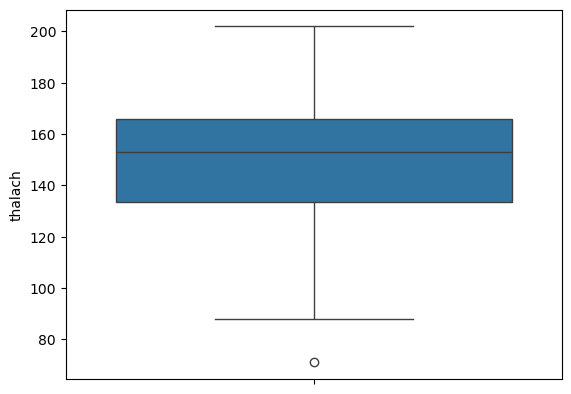

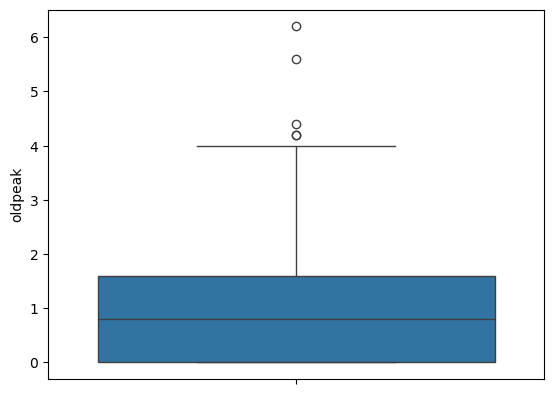

In [10]:
# some columns like trestbps,chol,thalach,oldpeak contains the outlier but i am not removing them according to domain knowledge it affects the final prediction

for col in num_col:
    plt.figure()
    sns.boxplot(df[col])
    plt.show()

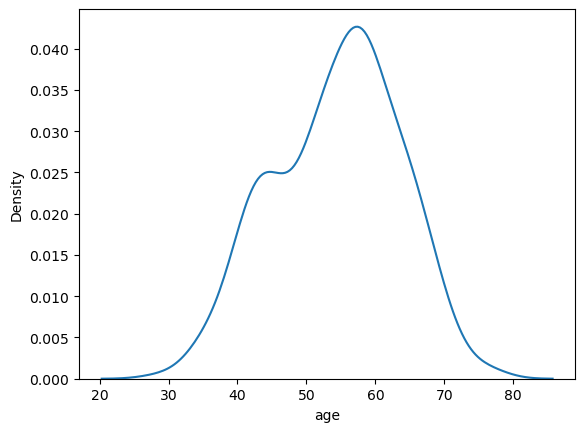

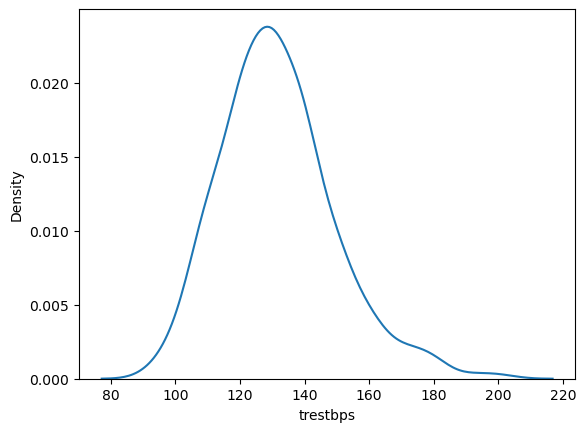

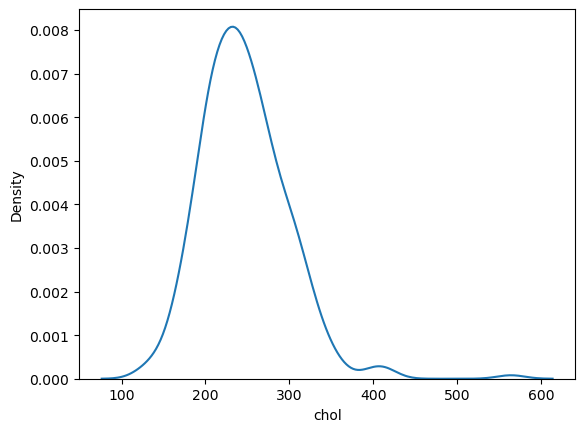

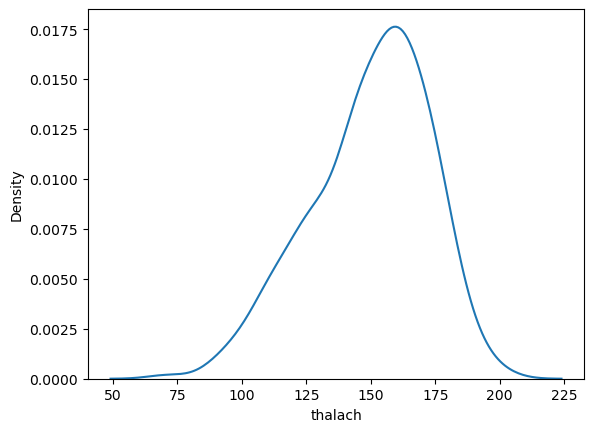

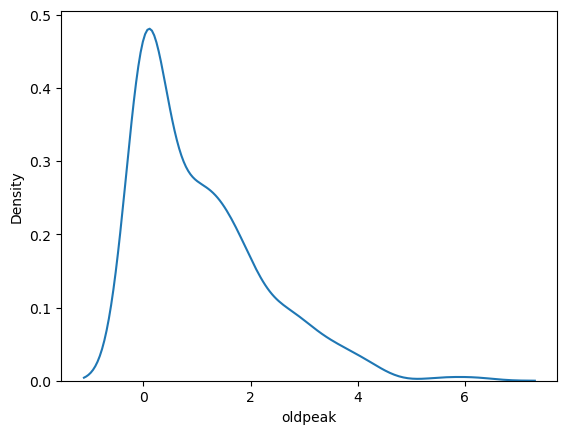

In [11]:
# all columns are highly skewed
# left skewness - age, thalach
# right skewness - trestbps, chol, oldpeak
# according to my understanding i am not removing the skewness because it directly impact on my features
for col in num_col:
    plt.figure()
    sns.kdeplot(df[col])
    plt.show()

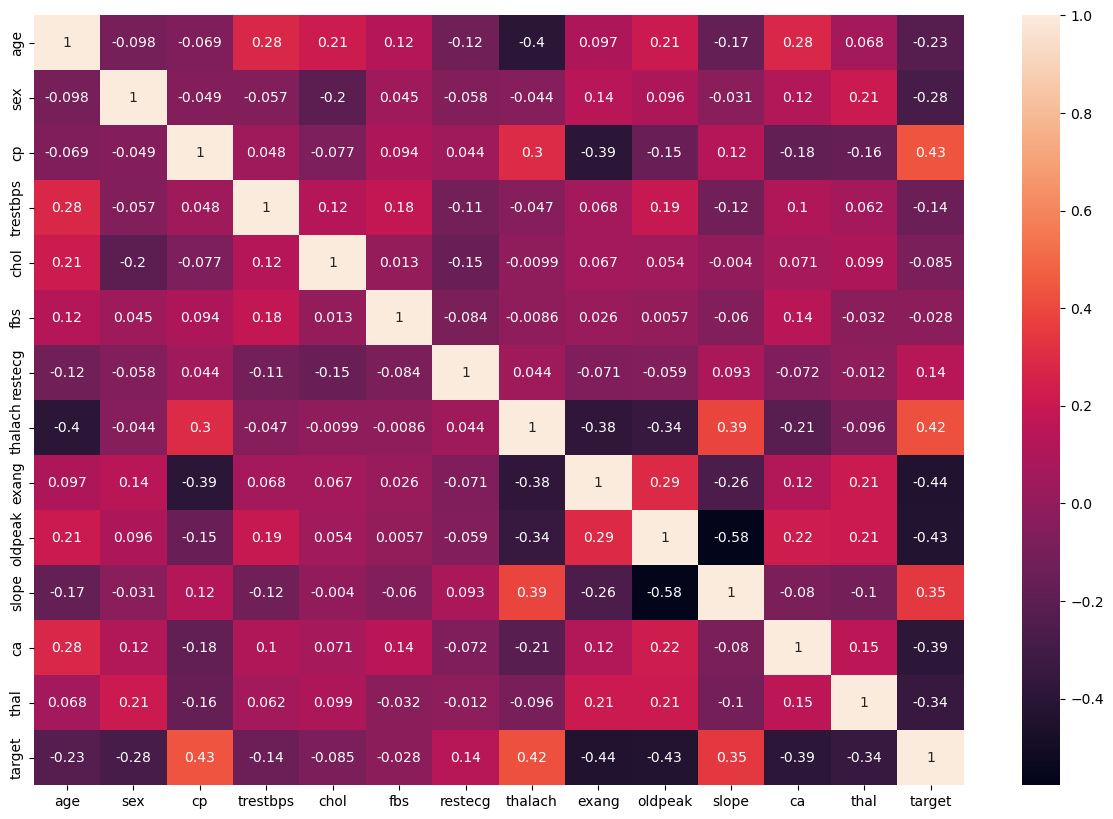

In [12]:
# cp and slope are highly correlated with target column
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(), annot = True)
plt.show()

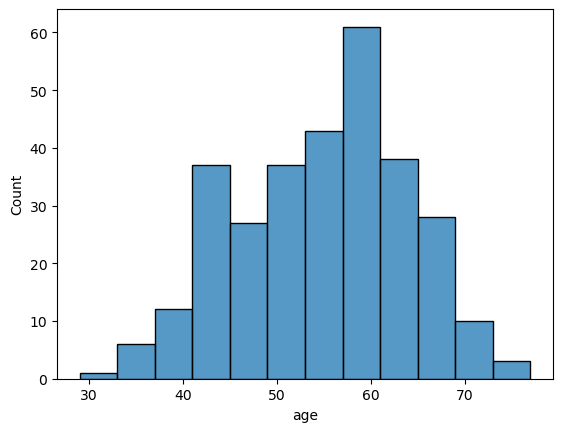

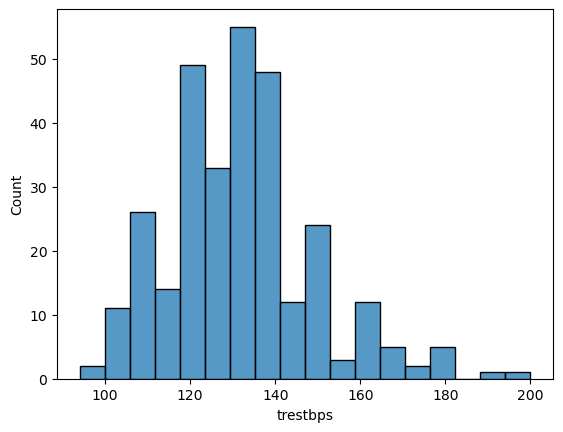

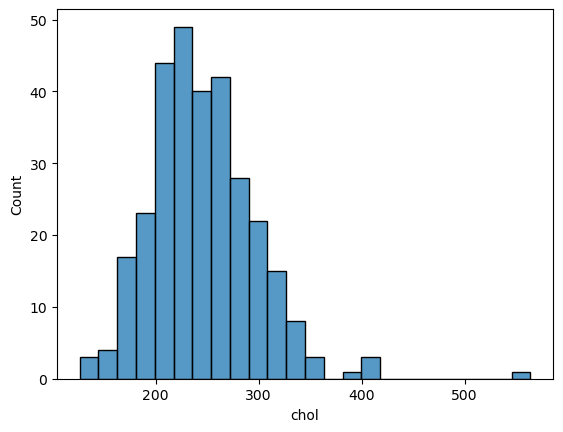

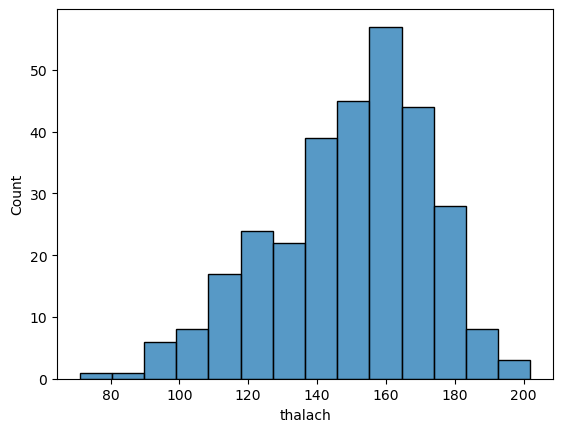

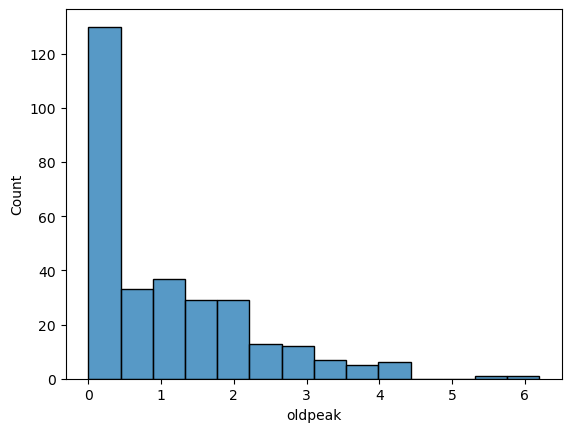

In [13]:
for col in num_col:
    plt.figure()
    sns.histplot(df[col])
    plt.show()

In [14]:
x = df.drop("target", axis=1) # independent variables
y = df["target"] # dependent variable

In [15]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [16]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [17]:
x_duplicate = x

In [18]:
# scalling the independent varible for better result
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_scal = ss.fit_transform(x)
x = pd.DataFrame(x_scal)

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.30, random_state=42)

In [20]:
# x_train contains 212 rows and 13 columns for training the indipendence varibles
x_train.shape

(212, 13)

In [21]:
# 91 rows and 13 columns are used for the test
x_test.shape

(91, 13)

In [22]:
# y_train contains 212 rows for training dependent varible
y_train.shape

(212,)

In [23]:
# 91 rows are used for the test
y_test.shape

(91,)

**Logistic Regression**

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model = LogisticRegression()

In [26]:
# training data
model.fit(x_train, y_train)

LogisticRegression()

In [27]:
# prediction
y_pred = model.predict(x_test)
print(y_pred)

[0 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 1
 1 1 1 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 0 0 0 1 1 1 0 0 1 1 0 1]


In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,recall_score

In [29]:
print(classification_report(y_test,y_pred))
print("roc_auc score: ",roc_auc_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91

roc_auc score:  0.8102439024390243


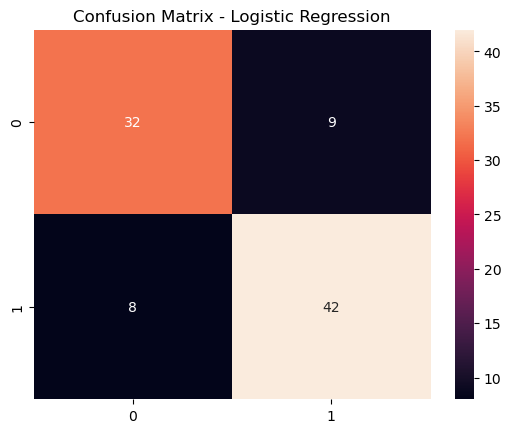

In [30]:
# false negative is dangeros for the heart desease prediction
cm = confusion_matrix(y_test,y_pred)
plt.figure()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
sns.heatmap(cm, annot =True)
plt.show()

After implementing the **loggistic regression** model i get 81% accuracy 

**Decision Tree Classifier**

In [31]:
# Decision Tree is used because it is simple, easy to understand, and makes decisions using if-else conditions.
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [32]:
dt = DecisionTreeClassifier()

In [33]:
dt.fit(x_train,y_train)

DecisionTreeClassifier()

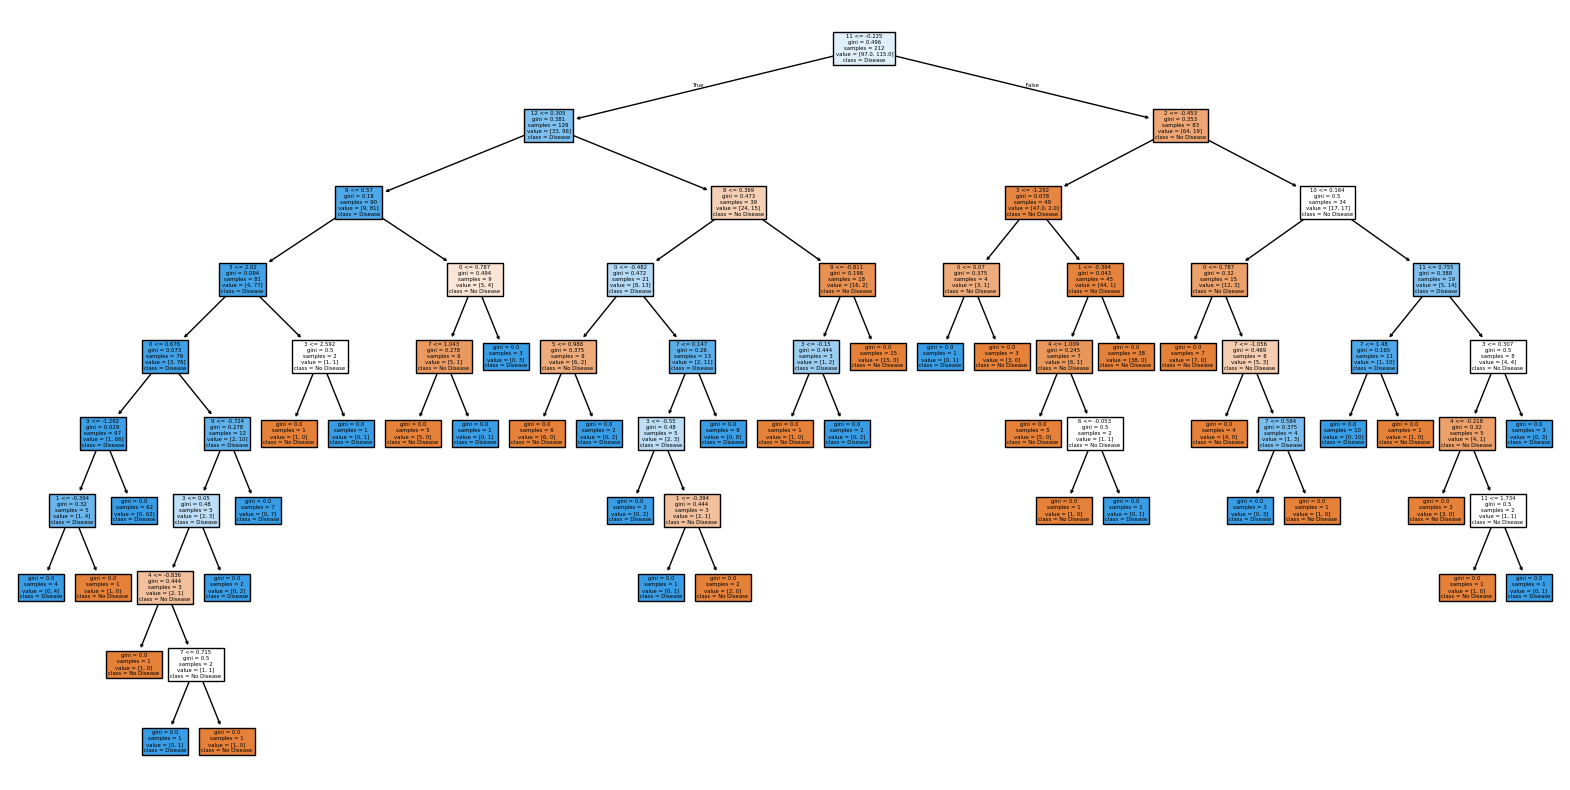

In [34]:
plt.figure(figsize = (20,10))
plot_tree(dt, feature_names = x.columns, class_names = ["No Disease", "Disease"],filled = True)
plt.show()

In [35]:
dt_pred = dt.predict(x_test)
print(dt_pred)

[0 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 1 1 0 1 0 0 0 0 1 0 0
 0 0 1 1 1 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 0 0 0 1 0 0 1 0 0 1 1 1 1 1 1 1
 0 1 1 0 0 0 1 0 1 0 0 0 0 1 0 0 1]


In [36]:
print(classification_report(y_test,dt_pred))
print("roc_auc score: ",roc_auc_score(y_test,dt_pred))
dt_score = accuracy_score(y_test,dt_pred)
dt_recall = recall_score(y_test,dt_pred)

              precision    recall  f1-score   support

           0       0.67      0.80      0.73        41
           1       0.81      0.68      0.74        50

    accuracy                           0.74        91
   macro avg       0.74      0.74      0.74        91
weighted avg       0.75      0.74      0.74        91

roc_auc score:  0.7424390243902441


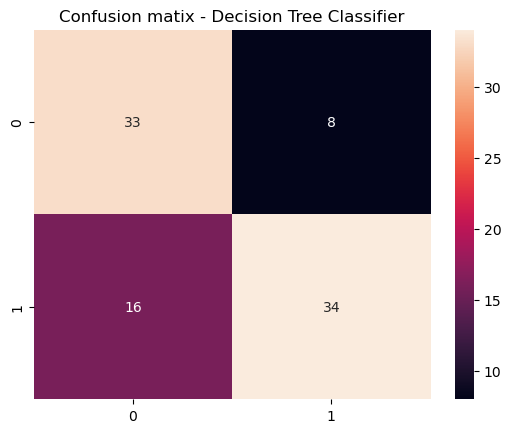

In [37]:
cm_1 = confusion_matrix(y_test, dt_pred)
plt.figure()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matix - Decision Tree Classifier")
sns.heatmap(cm_1, annot = True)
plt.show()

After implementing Decision Tree i get accuracy 70%, roc_auc_score 71%, recall 64%. that means Logistic Regrassion is performing well

**Hyperparameter tunning on Decision tree**

In [38]:
from sklearn.model_selection import GridSearchCV

In [39]:
param_grid = {
    "max_depth": [3,5,7, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [40]:
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="recall"
)

In [41]:
dt_grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='recall')

In [42]:
best_dt = dt_grid.best_estimator_

In [43]:
print("best parameters: ", dt_grid.best_params_)

best parameters:  {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [44]:
y_pred_best_dt = best_dt.predict(x_test)
tunned_recall = recall_score(y_test, y_pred_best_dt)

print("Tuned Decision Tree Accuracy:", tunned_recall)


Tuned Decision Tree Accuracy: 0.76


In [45]:
print("Before Tuning recall:", dt_recall)
print("After Tuning recall :", tunned_recall)

Before Tuning recall: 0.68
After Tuning recall : 0.76


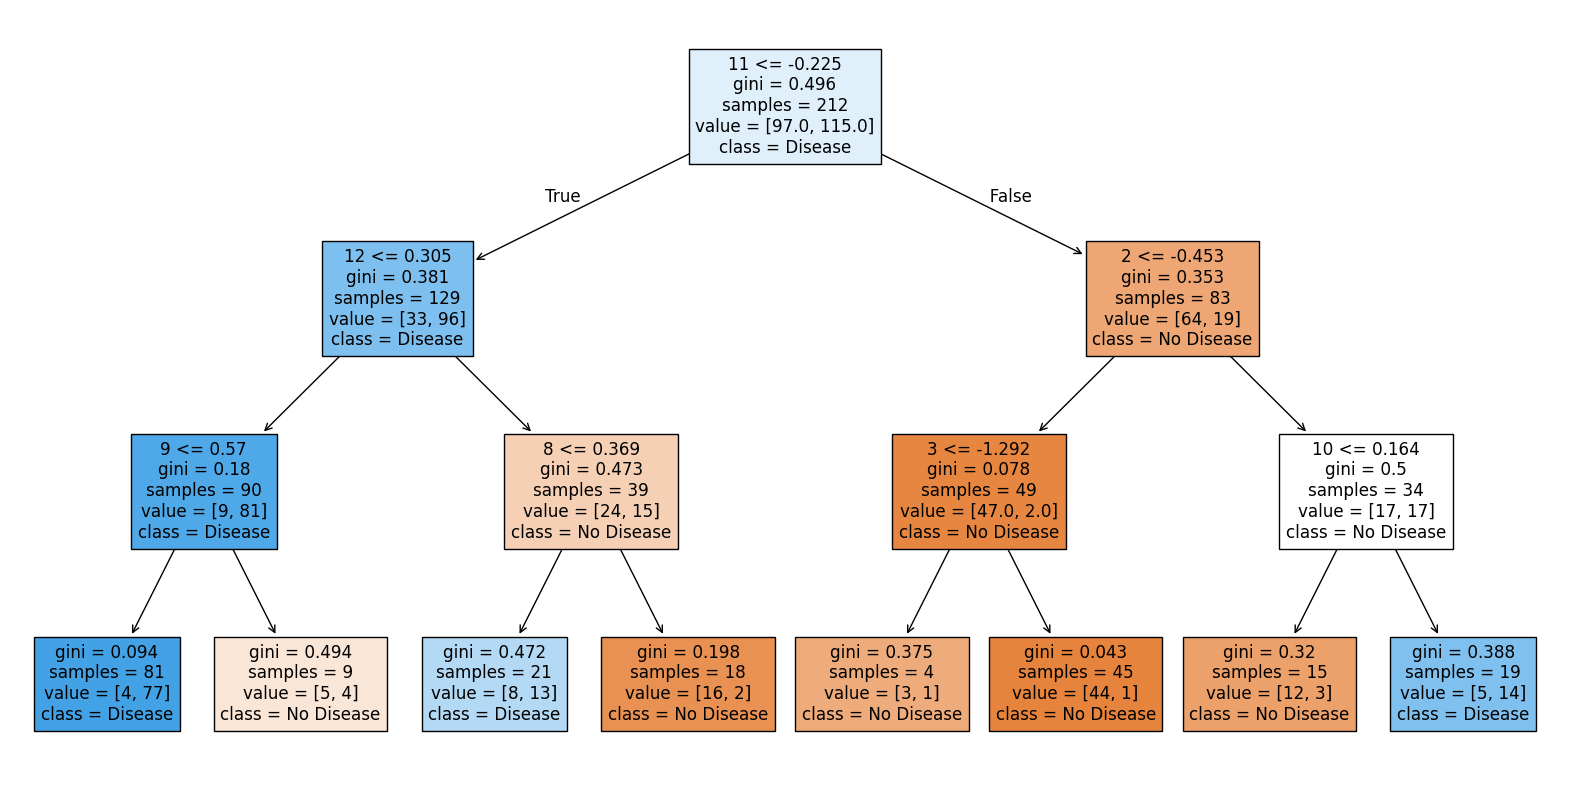

In [46]:
plt.figure(figsize = (20,10))
plot_tree(best_dt, feature_names = x.columns, class_names = ["No Disease", "Disease"],filled = True)
plt.show()

Hyperparameter tuning was applied to the Decision Tree classifier using GridSearchCV with 5-fold cross-validation. Parameters such as maximum depth and minimum samples per split were optimized to reduce overfitting and improve generalization performance.

**Random Forest Classifier**

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf = RandomForestClassifier()

In [49]:
# traning
rf.fit(x_train, y_train)

RandomForestClassifier()

In [50]:
rf_pred = rf.predict(x_test)
print(rf_pred)

[0 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 1]


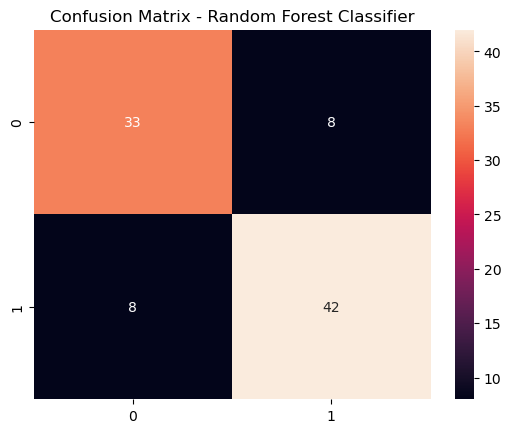

In [51]:
cm_2 = confusion_matrix(y_test, rf_pred)
plt.figure()
plt.xlabel("Predication")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Classifier")
sns.heatmap(cm_2, annot = True)
plt.show()

In [52]:
print(classification_report(y_test,rf_pred))
print("roc_auc score: ",roc_auc_score(y_test,rf_pred))
print()

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        41
           1       0.84      0.84      0.84        50

    accuracy                           0.82        91
   macro avg       0.82      0.82      0.82        91
weighted avg       0.82      0.82      0.82        91

roc_auc score:  0.8224390243902439



Random Forest Classifier is performing better than Logistic Regression and Decision Tree Classifier

**HyperParameter tunning on RandomForestClassifier**

In [53]:
from sklearn.model_selection import RandomizedSearchCV

In [54]:
param_dist = {
    "n_estimators": [100,200,300],
    "max_depth": [5,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [55]:
rf_random = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state = 42),
    param_distributions = param_dist,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

In [56]:
rf_random.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='roc_auc')

In [57]:
best_rf = rf_random.best_estimator_

print("Best Parameters:", rf_random.best_params_)


Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5}


In [58]:
from sklearn.metrics import recall_score
y_pred_best_rf = best_rf.predict(x_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Tuned RF Recall  :", recall_score(y_test, y_pred_best_rf))
print("Tuned RF ROC-AUC :", roc_auc_score(y_test, y_pred_best_rf))

Tuned RF Accuracy: 0.8241758241758241
Tuned RF Recall  : 0.86
Tuned RF ROC-AUC : 0.8202439024390243


In [59]:
print("----- Comparison -----")
print("Default RF Recall :", recall_score(y_test, rf_pred))
print("Tuned RF Recall   :", recall_score(y_test, y_pred_best_rf))

----- Comparison -----
Default RF Recall : 0.84
Tuned RF Recall   : 0.86


Hyperparameter tuning was applied to the Random Forest classifier using RandomizedSearchCV with 5-fold cross-validation. Parameters such as number of trees, maximum depth, and minimum samples per split were optimized. ROC-AUC was used as the scoring metric to prioritize recall and overall diagnostic performance.

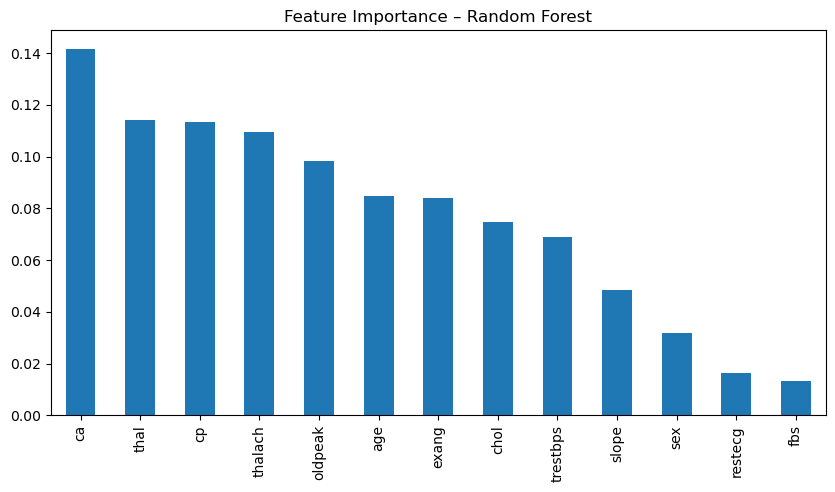

In [60]:
# Helps identify key risk factors for heart disease.
importances = pd.Series(rf.feature_importances_,index=x_duplicate.columns)
importances.sort_values(ascending=False).plot(kind = "bar",figsize=(10,5))
plt.title("Feature Importance – Random Forest")
plt.show()


**The Random Forest Classifier model achieved the best performance across all metrics. Due to its higher recall and ROC-AUC score, it is suitable for heart disease prediction where minimizing false negatives is critical.**